# Example 19: Impact of incidence angle and inhomogeneity

By default pyStrata propagates a **vertically incident, homogeneous** SH (SII) wave through the soil column -- the classical normal-incidence transfer-matrix solution. The `LinearElasticCalculator` (and the equivalent-linear calculators) also support the general viscoelastic solution of Borcherdt (*Viscoelastic Waves in Layered Media*, Ch. 9) through two keyword arguments, both given in **degrees**:

- **`incidence_angle`** ($\theta$) -- the angle of the wave at the base half-space measured from vertical. Oblique incidence changes the vertical wave number in each layer (Snell's law), which shifts the resonant frequencies and modifies the amplification. This is the **dominant** effect.
- **`inhomogeneity`** ($\gamma$) -- the angle between the wave's *propagation* vector (normal to planes of constant phase) and its *attenuation* vector (normal to planes of constant amplitude). A homogeneous wave has $\gamma = 0$.

**A note on the magnitude of the $\gamma$ effect.** The conserved quantity across the layer boundaries is the complex horizontal wave number $k = k_R - i\,k_I$. The real part $k_R = (\omega/V_s)\sin\theta$ is set by the incidence angle and is essentially independent of $\gamma$; the inhomogeneity perturbs only the *imaginary* part $k_I$, and that perturbation scales with the half-space intrinsic attenuation $1/Q$ (here $Q \approx 1/(2D)$). Two consequences, both shown below:

1. At **normal incidence** ($\theta = 0$) the real horizontal wave number vanishes, so $\gamma$ has essentially no effect on the 1-D transfer function.
2. At **oblique incidence** the $\gamma$ effect is a second-order correction proportional to the half-space $1/Q$ -- negligible for a stiff, low-loss rock half-space and only visible for a more attenuating base.

Because $\gamma$ is a property of the *incident wavefield* and cannot be derived from the profile alone, the honest way to use it is a **sensitivity sweep**. Here we hold the perturbation at **30° from vertical** and compare four cases:

| Case | $\theta$ | $\gamma$ |
| --- | --- | --- |
| Vertical, homogeneous (baseline) | 0° | 0° |
| Oblique incidence | 30° | 0° |
| Inhomogeneous | 0° | 30° |
| Both | 30° | 30° |

In [22]:
import matplotlib.pyplot as plt
import numpy as np

import pystrata

%matplotlib inline

In [23]:
# Increased figure sizes
plt.rcParams["figure.dpi"] = 120

## Input motion

A recorded acceleration time series is used as the input at the base outcrop. The incidence-angle and inhomogeneity options are independent of the motion type.

In [24]:
ts = pystrata.motion.TimeSeriesMotion.load_at2_file("data/NIS090.AT2")

## Site profile

A single damped soil layer over a half-space. The soil layer sets the fundamental resonance ($V_s/4H \approx 2.5$ Hz). We deliberately use a **moderately attenuating** half-space ($D = 0.08$, i.e. $Q \approx 6$ -- a weathered / soft-rock base) so that the inhomogeneity effect is visible; over a stiff low-loss rock half-space ($Q \gtrsim 30$) it would be sub-percent. The sensitivity to this choice is quantified in the last section.

In [25]:
profile = pystrata.site.Profile(
    [
        pystrata.site.Layer(pystrata.site.SoilType("Soil", 18.0, None, 0.03), 30, 300),
        pystrata.site.Layer(
            pystrata.site.SoilType("Weathered rock", 22.0, None, 0.08), 0, 900
        ),
    ]
)
print(f"Half-space quality factor Q = {profile[-1].soil_type.quality:.1f}")

Half-space quality factor Q = 6.2


## Define the cases and outputs

Each case is a `(incidence_angle, inhomogeneity)` pair in degrees. The same output collection is reused, naming each run so the results accumulate for comparison. The acceleration transfer function (surface / input outcrop) is the clearest diagnostic; the surface response spectrum is included as a familiar engineering measure.

In [39]:
cases = {
    "Vertical, homogeneous": (0, 0),
    r"Oblique incidence ($\theta$=30°)": (30, 0),
    r"Inhomogeneous ($\gamma$=30°)": (0, 30),
    r"Both ($\theta$=$\gamma$=30°)": (30, 30),
}

freqs = np.logspace(-1, np.log10(30), num=400)

outputs = pystrata.output.OutputCollection(
    [
        pystrata.output.AccelTransferFunctionOutput(
            freqs,
            pystrata.output.OutputLocation("outcrop", index=-1),
            pystrata.output.OutputLocation("outcrop", index=0),
        ),
        pystrata.output.ResponseSpectrumOutput(
            freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            0.05,
        ),
    ]
)

## Run each case

A fresh calculator is built per case with the incidence angle and inhomogeneity applied; the baseline (0, 0) reproduces the classical vertical, homogeneous result.

In [40]:
for label, (incidence_angle, inhomogeneity) in cases.items():
    calc = pystrata.propagation.LinearElasticCalculator(
        incidence_angle=incidence_angle,
        inhomogeneity=inhomogeneity,
    )
    calc(ts, profile, profile.location("outcrop", index=-1))
    outputs(calc, label)

## Acceleration transfer functions

Oblique incidence pushes the fundamental peak to a slightly higher frequency (Snell's law shortens the vertical wave number) and lowers the peak amplification. The inhomogeneous case at *vertical* incidence overlies the baseline almost exactly, while the combined case separates from the oblique case -- the inhomogeneity signature only appears once $\theta \neq 0$.

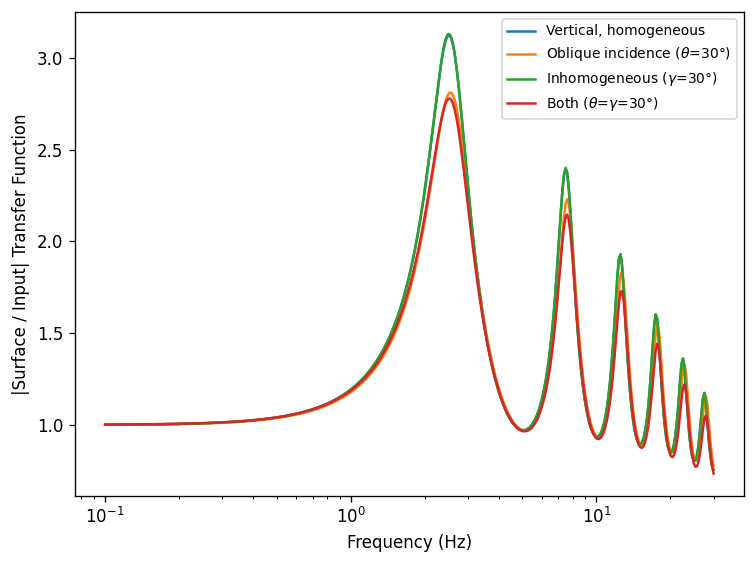

In [38]:
tf = outputs[0]

fig, ax = plt.subplots()
for name, ref_freqs, values in tf.iter_results():
    ax.plot(ref_freqs, values, label=name)
ax.set(
    xlabel="Frequency (Hz)",
    xscale="log",
    ylabel="|Surface / Input| Transfer Function",
)
ax.legend(fontsize="small")
fig.tight_layout();

### Ratio to the baseline

Dividing each transfer function by the vertical, homogeneous case isolates the effect of each perturbation. The incidence-angle effect is concentrated near the resonances; the inhomogeneity-only curve (at normal incidence) sits on 1.0, confirming that $\gamma$ alone does essentially nothing when $\theta = 0$. The combined case carries a visible additional offset from the oblique case -- that gap *is* the inhomogeneity contribution.

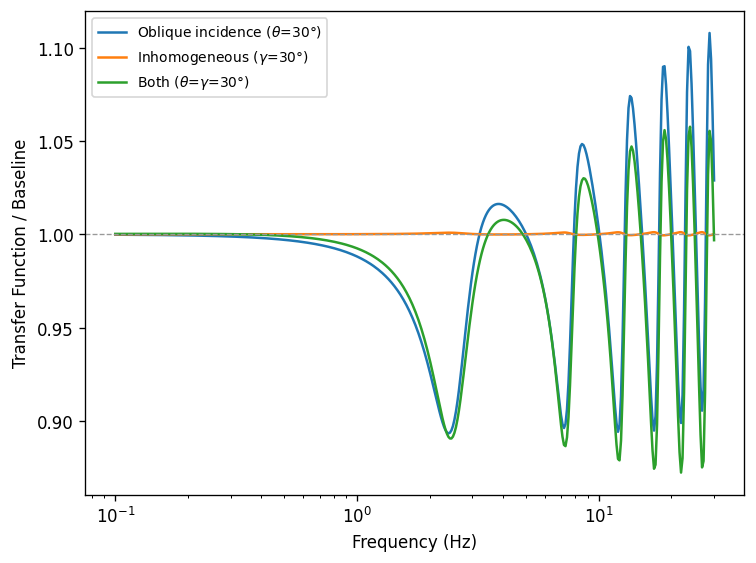

In [29]:
results = {name: np.asarray(values) for name, ref_freqs, values in tf.iter_results()}
baseline = results["Vertical, homogeneous"]

fig, ax = plt.subplots()
for name, values in results.items():
    if name == "Vertical, homogeneous":
        continue
    ax.plot(freqs, values / baseline, label=name)
ax.axhline(1.0, color="0.6", lw=0.8, ls="--")
ax.set(
    xlabel="Frequency (Hz)",
    xscale="log",
    ylabel="Transfer Function / Baseline",
)
ax.legend(fontsize="small")
fig.tight_layout();

## Surface response spectra

The same trends carry through to the 5%-damped surface response spectrum.

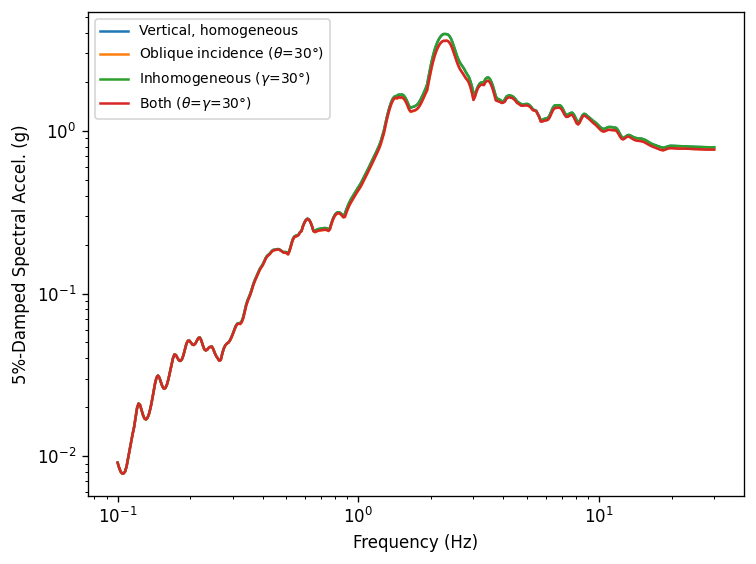

In [30]:
rs = outputs[1]

fig, ax = plt.subplots()
for name, ref_freqs, values in rs.iter_results():
    ax.plot(ref_freqs, values, label=name)
ax.set(
    xlabel="Frequency (Hz)",
    xscale="log",
    ylabel="5%-Damped Spectral Accel. (g)",
    yscale="log",
)
ax.legend(fontsize="small")
fig.tight_layout();

## Why the inhomogeneity effect scales with the half-space $1/Q$

To show that the small $\gamma$ influence above is physical (not an artifact), sweep the half-space damping and, for each value, measure the peak change in the transfer function caused by adding $\gamma = 30$° -- once at oblique incidence ($\theta = 30$°) and once at normal incidence ($\theta = 0$). The oblique-incidence effect grows **linearly with $1/Q$**, while the normal-incidence effect stays pinned near zero.

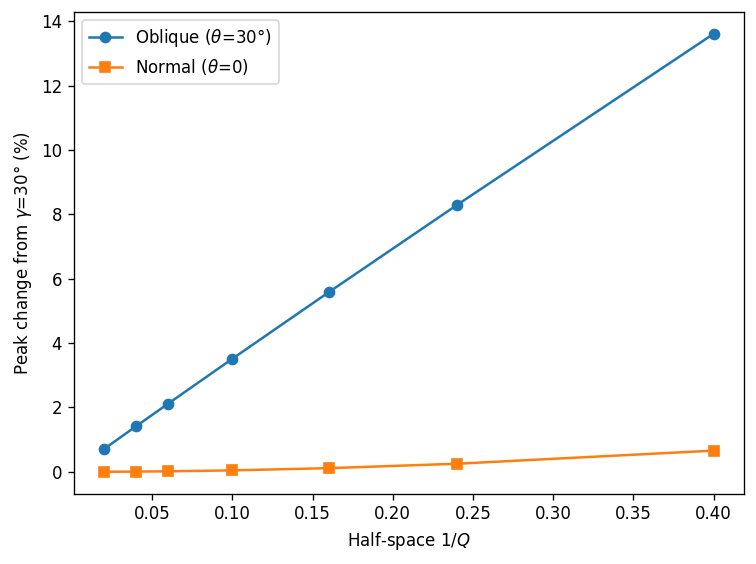

In [31]:
def tf_values(half_space_damping, incidence_angle, inhomogeneity):
    prof = pystrata.site.Profile(
        [
            pystrata.site.Layer(
                pystrata.site.SoilType("Soil", 18.0, None, 0.03), 30, 300
            ),
            pystrata.site.Layer(
                pystrata.site.SoilType("Half-space", 22.0, None, half_space_damping),
                0,
                900,
            ),
        ]
    )
    calc = pystrata.propagation.LinearElasticCalculator(
        incidence_angle=incidence_angle, inhomogeneity=inhomogeneity
    )
    calc(ts, prof, prof.location("outcrop", index=-1))
    out = pystrata.output.AccelTransferFunctionOutput(
        freqs,
        pystrata.output.OutputLocation("outcrop", index=-1),
        pystrata.output.OutputLocation("outcrop", index=0),
    )
    out(calc)
    return np.asarray(next(out.iter_results())[2]), prof[-1].soil_type.quality


dampings = [0.01, 0.02, 0.03, 0.05, 0.08, 0.12, 0.20]
inv_q, effect_oblique, effect_normal = [], [], []
for d in dampings:
    base_ob, q = tf_values(d, 30, 0)
    both_ob, _ = tf_values(d, 30, 30)
    base_no, _ = tf_values(d, 0, 0)
    both_no, _ = tf_values(d, 0, 30)
    inv_q.append(1.0 / q)
    effect_oblique.append(100 * np.max(np.abs(both_ob - base_ob) / base_ob))
    effect_normal.append(100 * np.max(np.abs(both_no - base_no) / base_no))

fig, ax = plt.subplots()
ax.plot(inv_q, effect_oblique, "o-", label=r"Oblique ($\theta$=30°)")
ax.plot(inv_q, effect_normal, "s-", label=r"Normal ($\theta$=0)")
ax.set(
    xlabel=r"Half-space $1/Q$",
    ylabel=r"Peak change from $\gamma$=30° (%)",
)
ax.legend()
fig.tight_layout();

## Summary of the peak shift

The fundamental peak frequency and amplification for each case quantify the trends above: the incidence angle moves the peak and lowers its amplitude, the inhomogeneity alone (at normal incidence) leaves the peak unchanged, and the combined case matches the oblique case with a small additional change.

In [32]:
print(f"{'Case':34s}{'f_peak (Hz)':>12s}{'peak amp.':>12s}")
for name, ref_freqs, values in tf.iter_results():
    values = np.asarray(values)
    i_peak = np.argmax(values)
    print(f"{name:34s}{ref_freqs[i_peak]:12.2f}{values[i_peak]:12.2f}")

Case                               f_peak (Hz)   peak amp.
Vertical, homogeneous                     2.49        3.12
Oblique incidence ($\theta$=30°)          2.53        2.81
Inhomogeneous ($\gamma$=30°)              2.49        3.12
Both ($\theta$=$\gamma$=30°)              2.53        2.79
